# Stream Benchmark Analysis

This notebook loads benchmark results from `stream_out.csv`, compares performance across environments, plots best rates by function, and calculates overhead relative to the native environment.

    Threads      Env Function  BestRate_MBs   AvgTime   MinTime   MaxTime  \
0        48   Native     Copy       61923.3  0.111394  0.111126  0.111702   
1        48   Native    Scale       61896.4  0.111325  0.111174  0.111513   
2        48   Native      Add       70279.8  0.147114  0.146869  0.147658   
3        48   Native    Triad       70507.8  0.146606  0.146394  0.146878   
4        48      SME     Copy       60713.7  0.113554  0.113340  0.113983   
5        48      SME    Scale       60688.5  0.113638  0.113387  0.114981   
6        48      SME      Add       68625.7  0.150852  0.150409  0.151225   
7        48      SME    Triad       68761.5  0.150396  0.150112  0.150735   
8        48  SME+SEV     Copy       60670.3  0.113809  0.113421  0.117716   
9        48  SME+SEV    Scale       60715.2  0.113842  0.113337  0.114319   
10       48  SME+SEV      Add       68578.3  0.151182  0.150513  0.152193   
11       48  SME+SEV    Triad       68751.3  0.150509  0.150134  0.150896   

Env
Native     0.000000
SME       -2.183803
SME+SEV   -2.211018
Name: Overhead_pct, dtype: float64

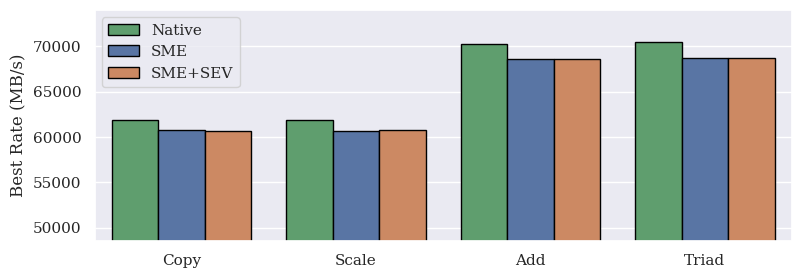

In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

sns.set_theme(style="darkgrid", font="serif") #TODO: fix with actual thesis font
base = sns.color_palette("deep", 3)
palette = {
	"Native": base[2],
	"SME": base[0],
	"SME+SEV": base[1]
}

df = pd.read_csv("/home/mengelsl/MA-bench-framework/outputs/stream/results.csv")

plt.figure(figsize=(9, 3))
ax = sns.barplot(data=df, x="Function", y="BestRate_MBs", hue="Env", edgecolor="black", palette=palette)
ax.set_ylim(df["BestRate_MBs"].min() * 0.8)
ax.set_ylabel("Best Rate (MB/s)")
ax.set_xlabel("")
ax.legend(title=None)
plt.savefig("stream_plot.pdf", bbox_inches="tight")

df_native = df[df["Env"] == "Native"].set_index("Function")
df["Overhead_pct"] = df.apply(lambda row: (row["BestRate_MBs"] - df_native.loc[row["Function"], "BestRate_MBs"]) / df_native.loc[row["Function"], "BestRate_MBs"] * 100, axis=1)
print(df)
df.groupby("Env")["Overhead_pct"].mean()